In [102]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


### Загрузка и проверка

Загружаем очищенный файл из первой тетрадки — 1337 строк без пропусков и дубликатов. Распределение таргета сверяем с первым этапом: среднее около 13279 при медиане 9386, смещение вправо сохраняется

In [103]:
# Загружаем данные
df = pd.read_csv('data/cleaned_data.csv')

# Быстрая проверка
print(f'Размер: {df.shape}') 
print(f"Пропуски: {df.isnull().sum().sum()}")
print(f"Дубликаты: {df.duplicated().sum()}")

df.rename(columns={'charges': 'target'}, inplace=True)
print(df["target"].describe())  

df.head()

Размер: (1337, 7)
Пропуски: 0
Дубликаты: 0
count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: target, dtype: float64


,age,sex,bmi,children,smoker,region,target
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Добавление новых признаков

Добавляем флаги родительства, многодетности и ожирения + категориальные признаки с группами возраста и BMI по фиксированным границам ВОЗ. Границы заданы заранее, а не по данным, поэтому утечки нет


In [104]:
# Бинарные признаки

df['is_parent'] = (df['children'] > 0).astype(int) 
df['is_many_children'] = (df['children'] > 3).astype(int)
df['is_obesity'] = (df['bmi'] >= 30).astype(int)


# Категориальные

df['age_group'] = pd.cut(df['age'], bins=[18, 30, 45, 60, 65], labels=['18-29', '30-44', '45-59', '60+'], right=False)
df['bmi_cat'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 35, 40, 100], 
                       labels=['deficit','normal','overweight','obesity1','obesity2','obesity3'], right=False)


In [105]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1337 entries, 0 to 1336
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               1337 non-null   int64   
 1   sex               1337 non-null   str     
 2   bmi               1337 non-null   float64 
 3   children          1337 non-null   int64   
 4   smoker            1337 non-null   str     
 5   region            1337 non-null   str     
 6   target            1337 non-null   float64 
 7   is_parent         1337 non-null   int64   
 8   is_many_children  1337 non-null   int64   
 9   is_obesity        1337 non-null   int64   
 10  age_group         1337 non-null   category
 11  bmi_cat           1337 non-null   category
dtypes: category(2), float64(2), int64(5), str(3)
memory usage: 107.4 KB


In [106]:
print(df.groupby(['bmi_cat','smoker'], observed=True)['target'].median().unstack())
print('\n')
print(df.groupby('age_group', observed=True)['target'].median())

smoker               no           yes
bmi_cat                              
deficit     3732.625100  15006.579450
normal      6593.508300  19479.903700
overweight  7063.915700  21215.433000
obesity1    7661.043725  39086.308625
obesity2    8671.191250  42118.090000
obesity3    7727.467125  45863.205000


age_group
18-29     3220.371575
30-44     6798.160625
45-59    11187.656700
60+      14255.400500
Name: target, dtype: float64


### Проверка новых признаков

Смотрим медианы: связка ожирения и курения уходит за 39000-45000, возраст строго растет 3220/6798/11187/14255


In [107]:
# Диагностика сплита: размеры выборок + распределение таргета + первые 3 строки 

def show_datasets(X_train, X_test, Y_train, Y_test):
    
    # DataFrame для обучающей выборки
    train_df = pd.DataFrame(
        data=X_train,
        columns=X_train.columns  
    )
    train_df['y'] = Y_train    

    # DataFrame для тестовой выборки
    test_df = pd.DataFrame(
        data=X_test,
        columns=X_test.columns
    )
    test_df['y'] = Y_test    

    print(f"Размер датасета Train {train_df.shape}")
    display(train_df.head(3))
    print(pd.Series(Y_train).describe()[['mean', '50%', 'std', 'min', 'max']])  
    
    print(f"Размер датасета Test {test_df.shape}")
    display(test_df.head(3))
    print(pd.Series(Y_test).describe()[['mean', '50%', 'std', 'min', 'max']])  


### Разделение на train/test

In [108]:
# Разделим на X и y: 80/20, random_state для воспроизводимости
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [109]:
show_datasets(X_train, X_test, y_train, y_test)

Размер датасета Train (1069, 12)


,age,sex,bmi,children,smoker,region,is_parent,is_many_children,is_obesity,age_group,bmi_cat,y
1113,23,male,24.510,0,no,northeast,0,0,0,18-29,normal,2396.09590
967,21,male,25.745,2,no,northeast,1,0,0,18-29,overweight,3279.86855
598,52,female,37.525,2,no,northwest,1,0,1,45-59,obesity2,33471.97189


mean    13030.203369
50%      9290.139500
std     11706.530971
min      1121.873900
max     62592.873090
Name: target, dtype: float64
Размер датасета Test (268, 12)


,age,sex,bmi,children,smoker,region,is_parent,is_many_children,is_obesity,age_group,bmi_cat,y
899,49,male,22.515,0,no,northeast,0,0,0,45-59,normal,8688.85885
1063,29,female,25.600,4,no,southwest,1,1,0,18-29,overweight,5708.86700
1255,51,female,36.385,3,no,northwest,1,0,1,45-59,obesity2,11436.73815


mean    14272.007559
50%      9535.650600
std     13581.026802
min      1131.506600
max     63770.428010
Name: target, dtype: float64


Фиксируем `random_state=42`, получаем 1069 строк в обучение и 268 в тест. Скейлер и кодировщик будут обучаться только на train внутри Pipeline


In [110]:
CAT_COLS = X.select_dtypes(include=['str', 'category']).columns.tolist()
NUM_COLS = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Контроль признаков
print(f"NUM = {len(NUM_COLS)} CAT = {len(CAT_COLS)} \ntotal = {len(NUM_COLS)+len(CAT_COLS)}")

NUM = 6 CAT = 5 
total = 11


In [111]:
# Создаем препроцессор: числа масштабируем, категории OHE drop=first от мультиколлинеарности
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), NUM_COLS),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), CAT_COLS)
    ],
)

In [112]:
# Сравнение моделей: один сплит и один препроцессор
models = {
 'Linear': LinearRegression(),
 'Ridge': Ridge(),
 'Lasso': Lasso(alpha=1.0),
 'RandomForest': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
 'SVR': SVR()
}

rows = []

for name, model in models.items():
  pipe = Pipeline([('prep', preprocessor), ('model', model)])
  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)
  rows.append([name, r2_score(y_test,y_pred), mean_squared_error(y_test,y_pred), 
               np.sqrt(mean_squared_error(y_test,y_pred)), mean_absolute_error(y_test,y_pred)])

res = pd.DataFrame(rows, columns=['model', 'R2', 'MSE', 'RMSE', 'MAE']).sort_values('R2', ascending=False)
print(res)

          model        R2           MSE          RMSE          MAE
3  RandomForest  0.879456  2.215065e+07   4706.447359  2666.483169
2         Lasso  0.798254  3.707202e+07   6088.679608  4399.589380
0        Linear  0.797928  3.713189e+07   6093.593999  4405.687322
1         Ridge  0.797828  3.715036e+07   6095.109206  4402.603146
4           SVR -0.133949  2.083701e+08  14435.029152  9272.854276


In [113]:
best_name = res.iloc[0,0]
print(f"Лучшая модель: {best_name}")

Лучшая модель: RandomForest


### Сравнение моделей: что видим

Пройдем все модели на одном сплите через Pipeline. Лидирует RandomForest с R2 около 0.88 и MAE около 2660 долларов, линейные модели дают R2 около 0.80 и MAE около 4400. SVR уходит в минус — дефолтный RBF не работает на суммах в десятки тысяч

### Подбор гиперпараметров леса


In [114]:
# Сетка леса
param_grid = {
    'model__n_estimators': [200, 300, 400], 
    'model__max_depth': [None, 10, 20, 30], 
    'model__min_samples_leaf': [1, 2, 3, 4, 5]}

In [115]:
# Бейз-пайп для GridSearch: препроцессор общий, меняется только лес
base_pipe = Pipeline([('prep', preprocessor), ('model', RandomForestRegressor(random_state=42))])

grid = GridSearchCV(
    estimator=base_pipe,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
)

In [116]:
# Обучаем модель и выводим лучшие параметры

grid.fit(X_train, y_train)

print(grid.best_params_, grid.best_score_)
best = grid.best_estimator_
pred_best = best.predict(X_test)

print(f"Test R2={r2_score(y_test,pred_best):.3f}\nMSE={mean_squared_error(y_test,pred_best):.0f}\nRMSE={np.sqrt(mean_squared_error(y_test,pred_best)):.0f}\nMAE={mean_absolute_error(y_test,pred_best):.0f}")

{'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__n_estimators': 400} 0.8368592154765999
Test R2=0.899
MSE=18590313
RMSE=4312
MAE=2449


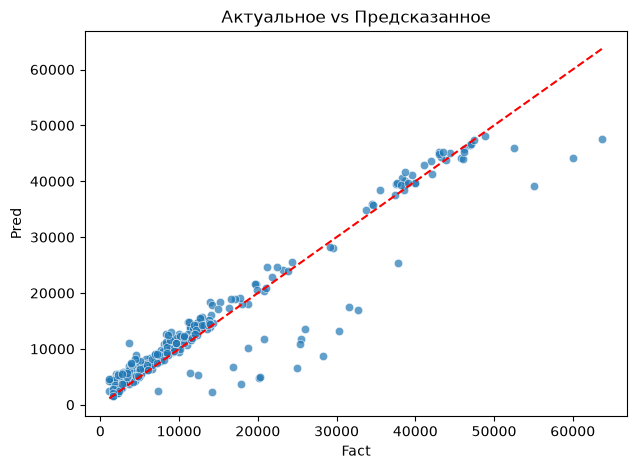

In [117]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=y_test, y=pred_best, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Fact') 
plt.ylabel('Pred') 
plt.title('Актуальное vs Предсказанное')
plt.savefig('img/actual_vs_pred.png', dpi=200, bbox_inches='tight')
plt.show()


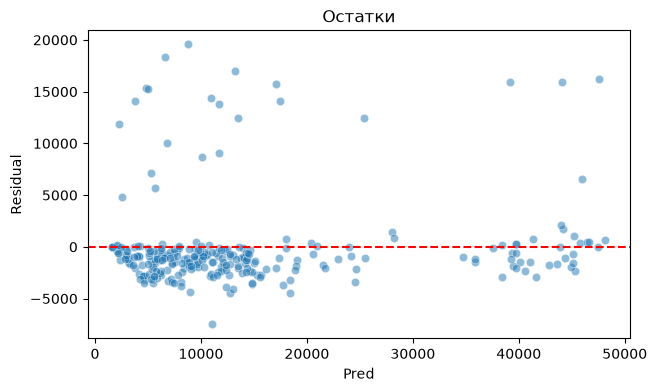

In [118]:
plt.figure(figsize=(7,4))
sns.scatterplot(x=pred_best, y=y_test-pred_best, alpha=0.5)
plt.axhline(0, color='r', linestyle='--') 
plt.xlabel('Pred') 
plt.ylabel('Residual')
plt.title('Остатки')
plt.savefig('img/residuals.png', dpi=200, bbox_inches='tight')
plt.show()

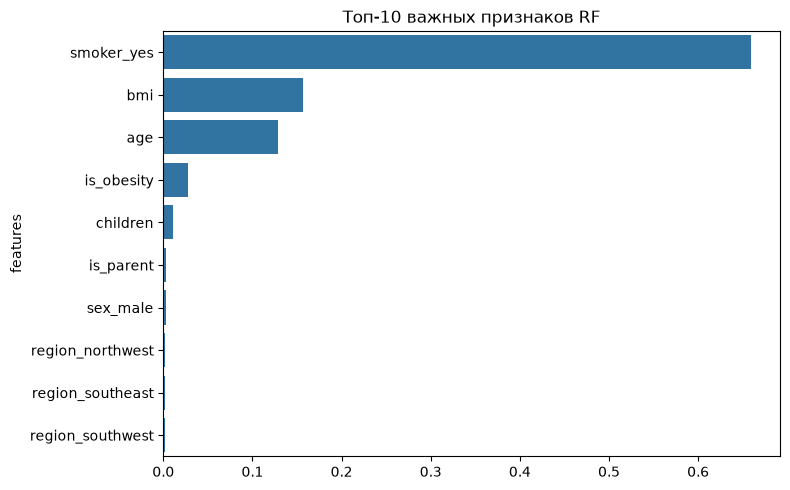

smoker_yes          0.658888
bmi                 0.156691
age                 0.128878
is_obesity          0.027249
children            0.010336
is_parent           0.003265
sex_male            0.002896
region_northwest    0.002082
region_southeast    0.002003
region_southwest    0.001730
dtype: float64


In [119]:
# Топ 10 признаков
ohe = best.named_steps['prep'].named_transformers_['cat'].get_feature_names_out(CAT_COLS)
feat_names = NUM_COLS + list(ohe)
imp = pd.Series(best.named_steps['model'].feature_importances_, index=feat_names).sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5)) 
sns.barplot(x=imp.values, y=imp.index)
plt.title('Топ-10 важных признаков RF')
plt.ylabel('features')
plt.tight_layout() 
plt.savefig('img/feat_imp.png', dpi=200, bbox_inches='tight') 
plt.show()
print(imp)

### Диагностика: что показывают остатки и важности

Точки Fact vs Pred идут вдоль диагонали двумя облаками — это курильщики и остальные. На дорогих полисах ошибаемся сильнее. 

По важностям леса лидирует признак `smoker_yes`, дальше `bmi` и `age`, регион около нуля.


In [120]:
import os

os.makedirs('models', exist_ok=True)
joblib.dump(best, 'models/model.pkl')
pd.DataFrame({'y_test':y_test.values, 'y_pred':pred_best}).to_csv('data/test_predictions.csv', index=False)
print('saved models/model.pkl + data/test_predictions.csv')

saved models/model.pkl + data/test_predictions.csv


## Итог проекта
Цель — заранее оценивать стоимость полиса.

Данные Medical Cost `1337 записей x 7 исходных признаков` без пропусков, один полный дубликат удален, поэтому работаем с чистой выборкой. Таргет `charges` сильно скошен вправо `mean 13279 против median 9386`, значит смотрим качество по `R2`, а деньги считаем по `RMSE` и `MAE`.

Анализ показал понятные триггеры: курильщики дороже в разы `median 34456 против 7345`, в разрезе BMI разрыв растет `normal 6593 против 19479, obesity1 7661 против 39086, obesity3 7727 против 45863`, возраст тянет вверх `18-29: 3220, 30-44: 6798, 45-59: 11187, 60+: 14255`, а пол `9412 против 9377`, регион `8798-10057` и дети `корреляция 0.07` почти не влияют — дольше всех платят низкую стоимость молодые некурящие с нормальным весом.

Для модели добавили 3 флага и собрали все в `Pipeline`: `StandardScaler` для чисел, `OneHotEncoder(drop=first)` для категорий, обучение строго внутри `train 1069 / test 268` с `random_state=42`.

Сравнили 5 моделей, лучшей стал `RandomForest` с `R2 0.879, RMSE 4706, MAE 2666`, после тюнинга `n_estimators/max_depth/min_samples_leaf` по `GridSearchCV 5-fold` он дает `R2 0.899 при RMSE 4312 и MAE 2449`: средняя ошибка около двух с половиной тысяч при ценах от 1 до 63 тысяч, а линейки остались на `R2 0.80, MAE 4400`.

Важные признаки модели совпадают с аналитикой — `smoker_yes 0.66`, дальше `bmi 0.16` и `age 0.13`, регион и пол около нуля.

Ограничение: данных всего 1337 и это точечная оценка, остатки веером на дорогих полисах

## Демо: как модель предсказывает стоимость


In [121]:
def add_features(d):
  d = d.copy()
  d['is_obesity'] = (d['bmi'] >= 30).astype(int)
  d['is_parent'] = (d['children'] > 0).astype(int)
  d['is_many_children'] = (d['children'] > 3).astype(int)

  d['age_group'] = pd.cut(d['age'], bins=[18, 30, 45, 60, 65], labels=['18-29', '30-44', '45-59', '60+'], right=False) 
  d['bmi_cat'] = pd.cut(d['bmi'], bins=[0, 18.5, 25, 30, 35, 40, 100], 
                       labels=['deficit','normal','overweight','obesity1','obesity2','obesity3'], right=False)

  return d


In [122]:
best = joblib.load('models/model.pkl')

new = pd.DataFrame([
 {'age':25, 'sex':'female', 'bmi':22.5, 'children':0, 'smoker':'no', 'region':'southwest'},
 {'age':45, 'sex':'male', 'bmi':34.0, 'children':2, 'smoker':'yes', 'region':'southeast'},
 {'age':52, 'sex':'female', 'bmi':31.5, 'children':1, 'smoker':'yes', 'region':'northwest'},
])

new_fe = add_features(new)
pred = best.predict(new_fe)

for i, p in enumerate(pred):
  print(f"Клиент {i+1}: {new.iloc[i].to_dict()} -> прогноз ${p:.0f}")

Клиент 1: {'age': 25, 'sex': 'female', 'bmi': 22.5, 'children': 0, 'smoker': 'no', 'region': 'southwest'} -> прогноз $5699
Клиент 2: {'age': 45, 'sex': 'male', 'bmi': 34.0, 'children': 2, 'smoker': 'yes', 'region': 'southeast'} -> прогноз $43413
Клиент 3: {'age': 52, 'sex': 'female', 'bmi': 31.5, 'children': 1, 'smoker': 'yes', 'region': 'northwest'} -> прогноз $44105
